In [1]:
import chess as ch
import random as rd
import pandas as pd
import numpy as np
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import time
import torch
from torch import nn as nn
import math
from glob import glob
from torchsummary import summary
from torch_snippets.torch_loader import Report
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image 

from stockfish import Stockfish
from sklearn.utils import shuffle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
torch.cuda.is_available()
print(device)

cuda


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

True
0
NVIDIA GeForce RTX 3070


# Pieces 

In [4]:
class PieceClassifier(nn.Module):
    def __init__(self):
        super(PieceClassifier, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=12, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Dropout(p=0.25),
            nn.Linear(512 * 1 * 1, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Dropout(p=0.25),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            nn.Linear(512, 6)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


In [5]:
class PieceDataset(Dataset):
    def __init__(self, datax, datay):
        self.x = torch.from_numpy(datax).type(torch.FloatTensor)
        self.y = torch.from_numpy(datay).type(torch.FloatTensor)
        self.n_samples = datax.shape[0]
    
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return self.n_samples

In [ ]:
print("Loading Data")
data_x = np.load('../Datasets/Moves/train/pieces/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/pieces/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = PieceDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = PieceDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 6893472
Test: 1723369


In [7]:
model_PC = PieceClassifier()
model_PC.to(device)
model_PC.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_PC.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/pieceClassifier.pth'

for epoch in range(num_epochs):

    model_PC.train()
    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0

        pos, piece = data

        pos = pos.to(device)
        piece = piece.to(device).long()
        
        pred = model_PC(pos)
        
        loss = criterion(pred, piece)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(pred, 1)
        total += piece.size(0)
        right += (predicted == piece).sum().item()

        acc = right / total * 100
        

        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_PC.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, piece = data

            pos = pos.to(device)
            piece = piece.to(device).long()


            pred = model_PC(pos)

            loss = criterion(pred, piece)

            _, predicted = torch.max(pred, 1)
            total += piece.size(0)
            right += (predicted == piece).sum().item()


            acc = right / total * 100
            

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_PC.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 0.904  val_acc: 61.858  trn_loss: 0.936  trn_acc: 60.357  (1977.64s - 17798.72s remaining)
EPOCH: 4.000  val_loss: 0.852  val_acc: 64.421  trn_loss: 0.855  trn_acc: 64.369  (3676.74s - 14706.95s remaining)
EPOCH: 6.000  val_loss: 0.827  val_acc: 65.648  trn_loss: 0.801  trn_acc: 66.729  (5359.96s - 12506.57s remaining)
EPOCH: 8.000  val_loss: 0.824  val_acc: 65.778  trn_loss: 0.789  trn_acc: 67.229  (7066.65s - 10599.98s remaining)
EPOCH: 10.000  val_loss: 0.823  val_acc: 65.859  trn_loss: 0.782  trn_acc: 67.548  (8764.83s - 8764.83s remaining)
EPOCH: 12.000  val_loss: 0.822  val_acc: 65.903  trn_loss: 0.776  trn_acc: 67.805  (10441.14s - 6960.76s remaining)
EPOCH: 14.000  val_loss: 0.821  val_acc: 65.923  trn_loss: 0.775  trn_acc: 67.854  (12187.40s - 5223.17s remaining)
EPOCH: 16.000  val_loss: 0.821  val_acc: 65.928  trn_loss: 0.774  trn_acc: 67.885  (13886.15s - 3471.54s remaining)
EPOCH: 18.000  val_loss: 0.821  val_acc: 65.931  trn_loss: 0.774  trn_acc: 67

100%|██████████| 121/121 [00:49<00:00,  2.43it/s]


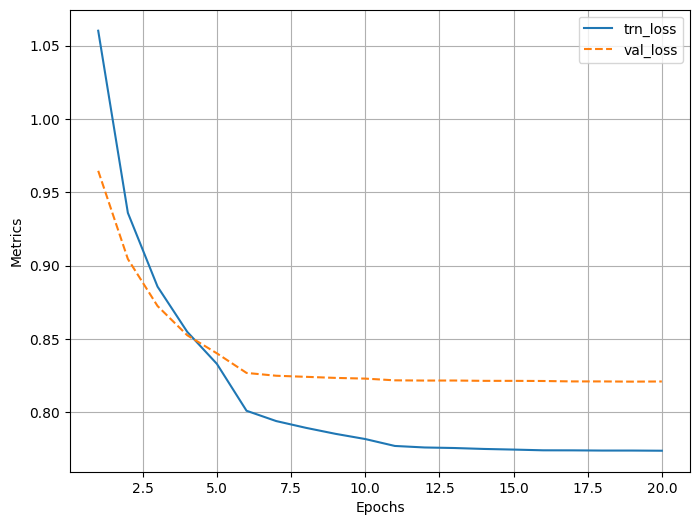

100%|██████████| 121/121 [00:48<00:00,  2.52it/s]


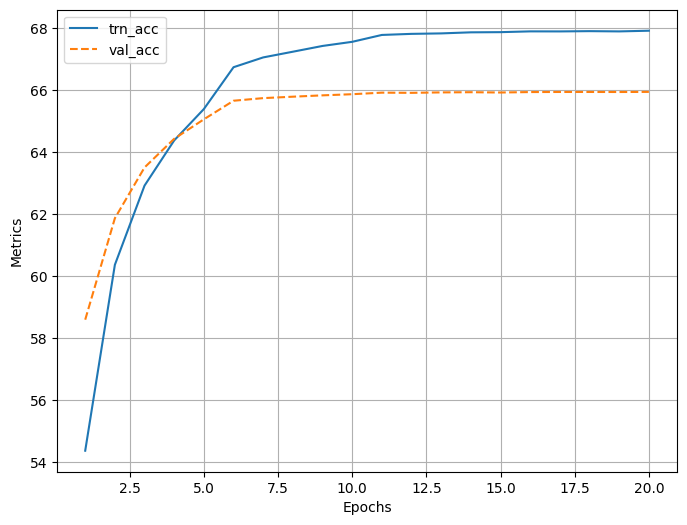

In [9]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Square

In [6]:
class SquareClassifier(nn.Module):
    def __init__(self):
        super(SquareClassifier, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=12, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Dropout(p=0.25),
            nn.Linear(512 * 1 * 1, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            
            nn.Dropout(p=0.25),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            nn.Linear(512, 64)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


In [7]:
class SquareDataset(Dataset):
    def __init__(self, datax, datay):
        self.x = torch.from_numpy(datax).type(torch.FloatTensor)
        self.y = torch.from_numpy(datay).type(torch.FloatTensor)
        self.n_samples = datax.shape[0]
    
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return self.n_samples

# Pawn

In [ ]:
print("Loading Data")
data_x = np.load('../Datasets/Moves/train/pawn/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/pawn/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 1820217
Test: 455055


In [13]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squarePawnClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 0.740  val_acc: 75.194  trn_loss: 0.853  trn_acc: 72.279  (449.35s - 4044.17s remaining)
EPOCH: 4.000  val_loss: 0.662  val_acc: 77.177  trn_loss: 0.681  trn_acc: 76.846  (896.71s - 3586.84s remaining)
EPOCH: 6.000  val_loss: 0.635  val_acc: 77.995  trn_loss: 0.597  trn_acc: 79.279  (1344.65s - 3137.51s remaining)
EPOCH: 8.000  val_loss: 0.633  val_acc: 78.071  trn_loss: 0.581  trn_acc: 79.796  (1791.80s - 2687.69s remaining)
EPOCH: 10.000  val_loss: 0.632  val_acc: 78.112  trn_loss: 0.570  trn_acc: 80.105  (2240.36s - 2240.36s remaining)
EPOCH: 12.000  val_loss: 0.630  val_acc: 78.162  trn_loss: 0.563  trn_acc: 80.368  (2688.34s - 1792.23s remaining)
EPOCH: 14.000  val_loss: 0.630  val_acc: 78.179  trn_loss: 0.561  trn_acc: 80.434  (3136.52s - 1344.22s remaining)
EPOCH: 16.000  val_loss: 0.630  val_acc: 78.181  trn_loss: 0.560  trn_acc: 80.457  (3583.87s - 895.97s remaining)
EPOCH: 18.000  val_loss: 0.630  val_acc: 78.182  trn_loss: 0.560  trn_acc: 80.463  (403

100%|██████████| 121/121 [00:13<00:00,  8.80it/s]


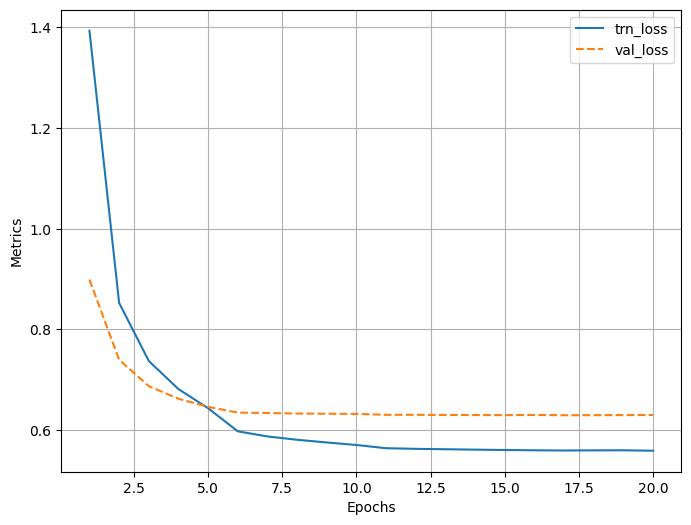

100%|██████████| 121/121 [00:13<00:00,  9.08it/s]


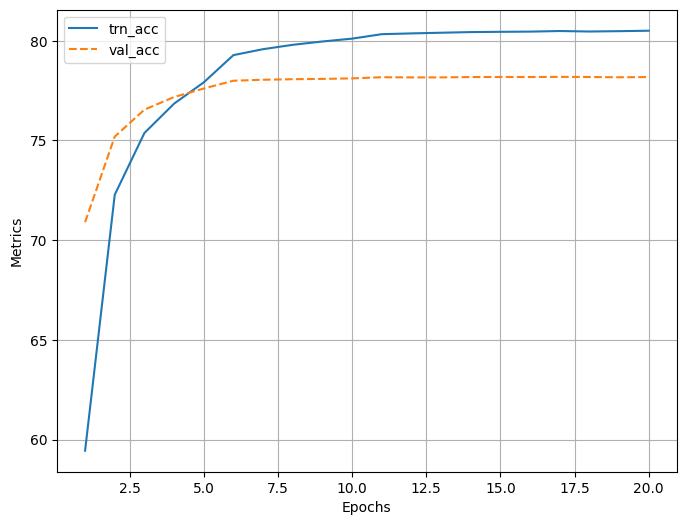

In [15]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Knight

In [ ]:

print("Loading Data")
data_x = np.load('../Datasets/Moves/train/knight/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/knight/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 1184412
Test: 296103


In [17]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squareKnightClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 0.947  val_acc: 67.728  trn_loss: 1.081  trn_acc: 64.442  (292.92s - 2636.26s remaining)
EPOCH: 4.000  val_loss: 0.806  val_acc: 72.301  trn_loss: 0.853  trn_acc: 71.231  (585.08s - 2340.30s remaining)
EPOCH: 6.000  val_loss: 0.754  val_acc: 74.058  trn_loss: 0.725  trn_acc: 75.240  (877.56s - 2047.64s remaining)
EPOCH: 8.000  val_loss: 0.748  val_acc: 74.286  trn_loss: 0.703  trn_acc: 75.939  (1170.18s - 1755.26s remaining)
EPOCH: 10.000  val_loss: 0.744  val_acc: 74.431  trn_loss: 0.688  trn_acc: 76.468  (1462.51s - 1462.51s remaining)
EPOCH: 12.000  val_loss: 0.743  val_acc: 74.508  trn_loss: 0.679  trn_acc: 76.732  (1753.16s - 1168.77s remaining)
EPOCH: 14.000  val_loss: 0.742  val_acc: 74.513  trn_loss: 0.677  trn_acc: 76.779  (2045.51s - 876.65s remaining)
EPOCH: 16.000  val_loss: 0.743  val_acc: 74.524  trn_loss: 0.676  trn_acc: 76.854  (2337.85s - 584.46s remaining)
EPOCH: 18.000  val_loss: 0.742  val_acc: 74.525  trn_loss: 0.675  trn_acc: 76.882  (2630.

100%|██████████| 121/121 [00:09<00:00, 12.91it/s]


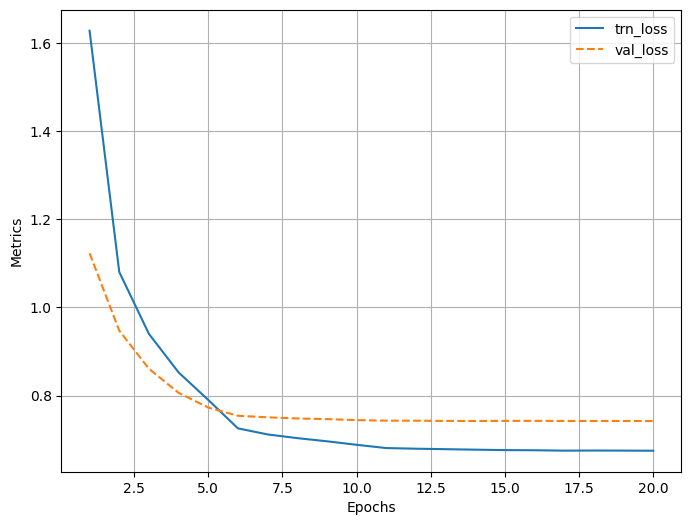

100%|██████████| 121/121 [00:09<00:00, 13.43it/s]


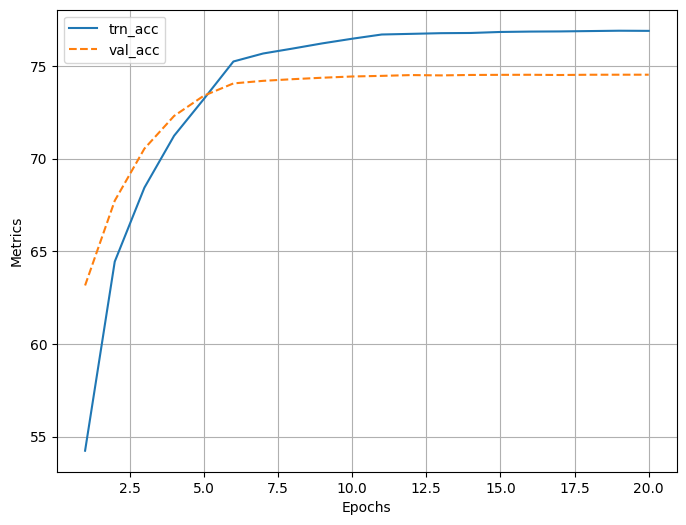

In [19]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Bishop

In [ ]:

print("Loading Data")
data_x = np.load('../Datasets/Moves/train/bishop/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/bishop/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 1023388
Test: 255847


In [21]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squareBishopClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)

        # Modify the loss function to handle multi-label classification
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 1.203  val_acc: 62.787  trn_loss: 1.378  trn_acc: 59.292  (253.68s - 2283.08s remaining)
EPOCH: 4.000  val_loss: 1.038  val_acc: 66.548  trn_loss: 1.094  trn_acc: 65.493  (507.30s - 2029.20s remaining)
EPOCH: 6.000  val_loss: 0.974  val_acc: 68.356  trn_loss: 0.941  trn_acc: 69.710  (760.62s - 1774.77s remaining)
EPOCH: 8.000  val_loss: 0.966  val_acc: 68.578  trn_loss: 0.915  trn_acc: 70.487  (1013.71s - 1520.56s remaining)
EPOCH: 10.000  val_loss: 0.961  val_acc: 68.763  trn_loss: 0.896  trn_acc: 71.023  (1265.95s - 1265.95s remaining)
EPOCH: 12.000  val_loss: 0.959  val_acc: 68.810  trn_loss: 0.885  trn_acc: 71.376  (1517.81s - 1011.87s remaining)
EPOCH: 14.000  val_loss: 0.958  val_acc: 68.825  trn_loss: 0.883  trn_acc: 71.427  (1771.37s - 759.16s remaining)
EPOCH: 16.000  val_loss: 0.958  val_acc: 68.853  trn_loss: 0.881  trn_acc: 71.516  (2024.83s - 506.21s remaining)
EPOCH: 18.000  val_loss: 0.958  val_acc: 68.817  trn_loss: 0.879  trn_acc: 71.533  (2277.

100%|██████████| 121/121 [00:08<00:00, 15.03it/s]


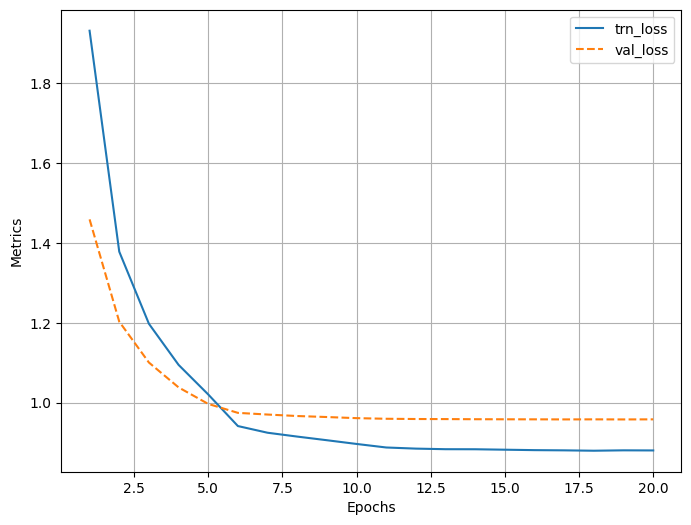

100%|██████████| 121/121 [00:07<00:00, 15.30it/s]


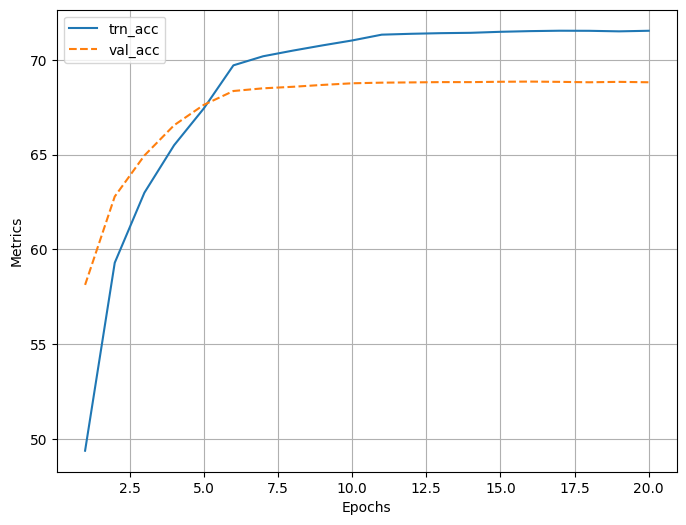

In [23]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Rook

In [ ]:

print("Loading Data")
data_x = np.load('../Datasets/Moves/train/rook/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/rook/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 999244
Test: 249812


In [25]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squareRookClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 2.089  val_acc: 37.129  trn_loss: 2.304  trn_acc: 32.385  (247.47s - 2227.19s remaining)
EPOCH: 4.000  val_loss: 1.799  val_acc: 45.121  trn_loss: 1.916  trn_acc: 42.266  (494.06s - 1976.23s remaining)
EPOCH: 6.000  val_loss: 1.695  val_acc: 47.856  trn_loss: 1.710  trn_acc: 47.804  (746.59s - 1742.05s remaining)
EPOCH: 8.000  val_loss: 1.681  val_acc: 48.222  trn_loss: 1.679  trn_acc: 48.695  (1000.68s - 1501.03s remaining)
EPOCH: 10.000  val_loss: 1.669  val_acc: 48.564  trn_loss: 1.658  trn_acc: 49.268  (1252.01s - 1252.01s remaining)
EPOCH: 12.000  val_loss: 1.667  val_acc: 48.587  trn_loss: 1.645  trn_acc: 49.648  (1503.58s - 1002.38s remaining)
EPOCH: 14.000  val_loss: 1.665  val_acc: 48.654  trn_loss: 1.641  trn_acc: 49.719  (1755.94s - 752.54s remaining)
EPOCH: 16.000  val_loss: 1.665  val_acc: 48.662  trn_loss: 1.639  trn_acc: 49.811  (2008.44s - 502.11s remaining)
EPOCH: 18.000  val_loss: 1.665  val_acc: 48.648  trn_loss: 1.639  trn_acc: 49.839  (2260.

100%|██████████| 121/121 [00:07<00:00, 15.13it/s]


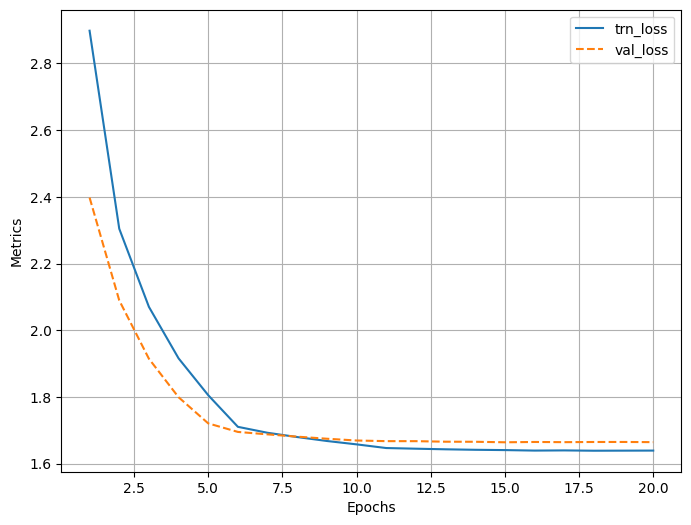

100%|██████████| 121/121 [00:07<00:00, 15.45it/s]


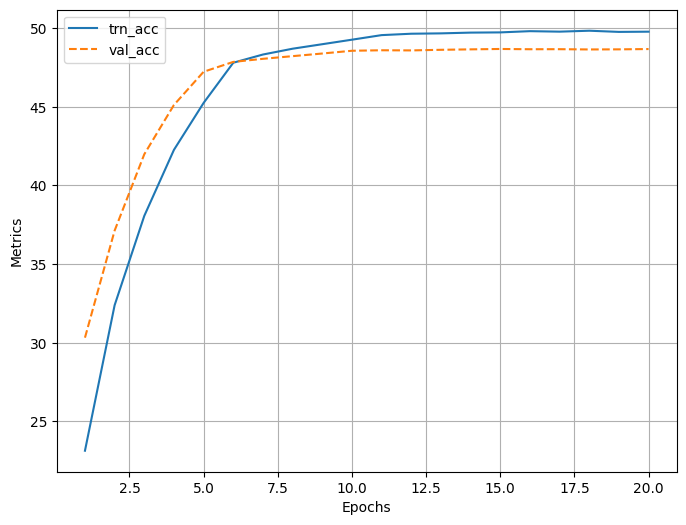

In [27]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Queen

In [ ]:

print("Loading Data")
data_x = np.load('../Datasets/Moves/train/queen/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/queen/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 866742
Test: 216686


In [29]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squareQueenClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 2.409  val_acc: 32.543  trn_loss: 2.636  trn_acc: 28.117  (213.90s - 1925.13s remaining)
EPOCH: 4.000  val_loss: 2.088  val_acc: 39.018  trn_loss: 2.209  trn_acc: 36.911  (427.18s - 1708.71s remaining)
EPOCH: 6.000  val_loss: 1.966  val_acc: 41.736  trn_loss: 1.977  trn_acc: 42.197  (640.44s - 1494.35s remaining)
EPOCH: 8.000  val_loss: 1.949  val_acc: 42.089  trn_loss: 1.942  trn_acc: 43.170  (853.51s - 1280.27s remaining)
EPOCH: 10.000  val_loss: 1.935  val_acc: 42.394  trn_loss: 1.916  trn_acc: 43.674  (1067.03s - 1067.03s remaining)
EPOCH: 12.000  val_loss: 1.931  val_acc: 42.428  trn_loss: 1.903  trn_acc: 44.075  (1280.55s - 853.70s remaining)
EPOCH: 14.000  val_loss: 1.930  val_acc: 42.488  trn_loss: 1.899  trn_acc: 44.145  (1493.54s - 640.09s remaining)
EPOCH: 16.000  val_loss: 1.929  val_acc: 42.494  trn_loss: 1.897  trn_acc: 44.258  (1707.06s - 426.77s remaining)
EPOCH: 18.000  val_loss: 1.929  val_acc: 42.487  trn_loss: 1.897  trn_acc: 44.213  (1920.20

100%|██████████| 121/121 [00:07<00:00, 16.97it/s]


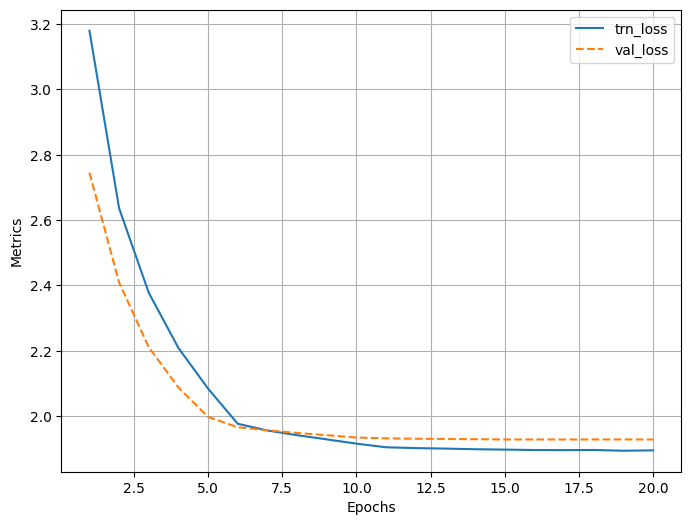

100%|██████████| 121/121 [00:06<00:00, 17.46it/s]


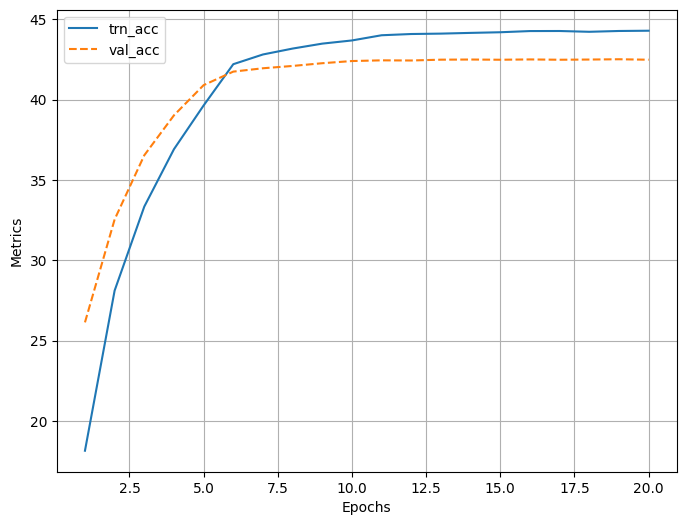

In [31]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# King

In [ ]:

print("Loading Data")
data_x = np.load('../Datasets/Moves/train/king/boards_squares_cnn_x_w.npy')
data_y = np.load('../Datasets/Moves/train/king/boards_squares_moved_cnn_x_w.npy')

data_x, data_y = shuffle(data_x, data_y)

datasetTrain = SquareDataset(data_x[:int(len(data_x)*.8)], data_y[:int(len(data_y)*.8)])
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=64)

datasetVal = SquareDataset(data_x[int(len(data_x)*.8):], data_y[int(len(data_y)*.8):])
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=64)

print(f"Train: {len(dataLoaderTrain.dataset)}")
print(f"Test: {len(dataLoaderVal.dataset)}")

Loading Data
Train: 775296
Test: 193825


In [33]:
model_SQ = SquareClassifier()
model_SQ.to(device)
model_SQ.train()

criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model_SQ.parameters(), lr=1e-5, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
start_time = time.time()

num_epochs = 20
log = Report(num_epochs)

PATH = '../Models/squareKingClassifier.pth'

for epoch in range(num_epochs):

    model_SQ.train()

    
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):

        total = 0
        right = 0
        
        pos, square = data

        pos = pos.to(device)
        square = square.to(device)

        pred = model_SQ(pos)
        loss = criterion(pred, square)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred_class = torch.argmax(pred, dim=1)
        true_class = torch.argmax(square, dim=1)

        right = (pred_class == true_class).sum().item()
        total = square.size(0)

        acc = right / total * 100

        
        log.record((epoch + (bx + 1) / N), trn_loss=loss, trn_acc=acc, end='\r')

    
    model_SQ.eval()

    N = len(dataLoaderVal)
    with torch.no_grad():
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, square = data

            pos = pos.to(device)
            square = square.to(device)

            pred = model_SQ(pos)

            loss = criterion(pred, square)

            pred_class = torch.argmax(pred, dim=1)
            true_class = torch.argmax(square, dim=1)

            right = (pred_class == true_class).sum().item()
            total = square.size(0)

            acc = right / total * 100

            log.record((epoch + (bx + 1) / N), val_loss=loss, val_acc=acc, end='\r')

    if (epoch + 1) % 2 == 0:
        log.report_avgs(epoch + 1)
    lr_scheduler.step()

torch.save({
    'epoch': epoch,
    'model_state_dict_PC': model_SQ.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': loss
}, PATH)


EPOCH: 2.000  val_loss: 1.115  val_acc: 58.683  trn_loss: 1.295  trn_acc: 52.363  (192.26s - 1730.32s remaining)
EPOCH: 4.000  val_loss: 0.914  val_acc: 65.708  trn_loss: 0.987  trn_acc: 63.552  (383.84s - 1535.37s remaining)
EPOCH: 6.000  val_loss: 0.836  val_acc: 68.462  trn_loss: 0.830  trn_acc: 69.227  (575.61s - 1343.09s remaining)
EPOCH: 8.000  val_loss: 0.827  val_acc: 68.743  trn_loss: 0.806  trn_acc: 70.120  (767.54s - 1151.32s remaining)
EPOCH: 10.000  val_loss: 0.820  val_acc: 68.996  trn_loss: 0.789  trn_acc: 70.729  (959.30s - 959.30s remaining)
EPOCH: 12.000  val_loss: 0.818  val_acc: 69.068  trn_loss: 0.780  trn_acc: 71.100  (1151.28s - 767.52s remaining)
EPOCH: 14.000  val_loss: 0.818  val_acc: 69.097  trn_loss: 0.777  trn_acc: 71.196  (1342.99s - 575.57s remaining)
EPOCH: 16.000  val_loss: 0.817  val_acc: 69.111  trn_loss: 0.775  trn_acc: 71.294  (1534.93s - 383.73s remaining)
EPOCH: 18.000  val_loss: 0.817  val_acc: 69.136  trn_loss: 0.775  trn_acc: 71.271  (1726.61s 

100%|██████████| 121/121 [00:06<00:00, 18.69it/s]


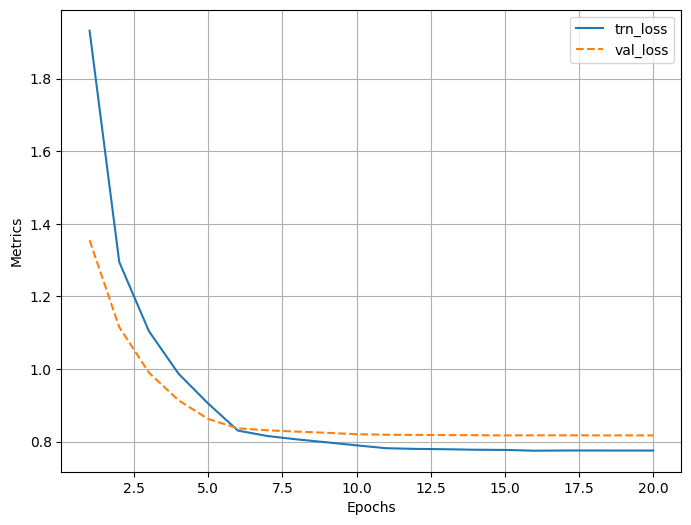

100%|██████████| 121/121 [00:06<00:00, 19.26it/s]


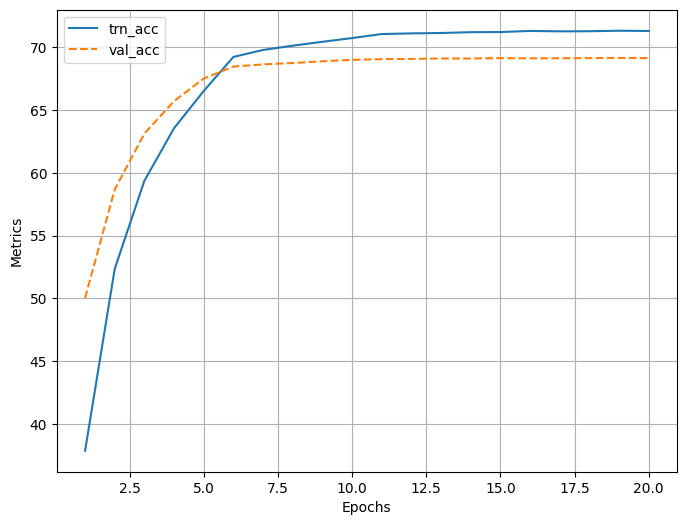

In [35]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

# Test

### Load Models

In [8]:
pieceModel = PieceClassifier()
checkpoint = torch.load("../Models/pieceClassifier.pth")
pieceModel.load_state_dict(checkpoint['model_state_dict_PC'])
pieceModel.to(device)
pieceModel.eval()

pawnModel = SquareClassifier()
checkpoint = torch.load("../Models/squarePawnClassifier.pth")
pawnModel.load_state_dict(checkpoint['model_state_dict_PC'])
pawnModel.to(device)
pawnModel.eval()

knightModel = SquareClassifier()
checkpoint = torch.load("../Models/squareKnightClassifier.pth")
knightModel.load_state_dict(checkpoint['model_state_dict_PC'])
knightModel.to(device)
knightModel.eval()

bishopModel = SquareClassifier()
checkpoint = torch.load("../Models/squareBishopClassifier.pth")
bishopModel.load_state_dict(checkpoint['model_state_dict_PC'])
bishopModel.to(device)
bishopModel.eval()

rookModel = SquareClassifier()
checkpoint = torch.load("../Models/squareRookClassifier.pth")
rookModel.load_state_dict(checkpoint['model_state_dict_PC'])
rookModel.to(device)
rookModel.eval()

queenModel = SquareClassifier()
checkpoint = torch.load("../Models/squareQueenClassifier.pth")
queenModel.load_state_dict(checkpoint['model_state_dict_PC'])
queenModel.to(device)
queenModel.eval()

kingModel = SquareClassifier()
checkpoint = torch.load("../Models/squareKingClassifier.pth")
kingModel.load_state_dict(checkpoint['model_state_dict_PC'])
kingModel.to(device)
kingModel.eval()

print("Loaded Models")


Loaded Models


In [9]:
def test_model(data, test_moves, fens, stockfish):
    total = 0

    cnn_hits = {1: 0, 2: 0, 3: 0}
    stock_hits = {1: 0, 2: 0, 3: 0}
    hybrid_hits = {1: 0, 2: 0, 3: 0}

    piece_models = [pawnModel, knightModel, bishopModel, rookModel, queenModel, kingModel]
    pieces_notation = [ch.PAWN, ch.KNIGHT, ch.BISHOP, ch.ROOK, ch.QUEEN, ch.KING]

    for ind in range(len(data)):

        move_prob = dict()

        pieces = pieceModel(data[ind].unsqueeze(0))
        pieces = pieces.cpu().detach().numpy().flatten()
        pieces = np.exp(pieces) / np.sum(np.exp(pieces))

        fen = fens[ind]
        board = ch.Board(fen=fen)
        legal_moves = list(board.legal_moves)

        for i in range(len(piece_models)):

            pred_to_squares = piece_models[i](data[ind].unsqueeze(0))
            squares = pred_to_squares.cpu().detach().numpy().flatten()
            squares = np.exp(squares) / np.sum(np.exp(squares))

            squares = (squares + pieces[i]) / 2

            square_pieces_board = board.pieces(pieces_notation[i], ch.WHITE)

            from_squares = [ch.square_name(sq) for sq in square_pieces_board]

            for j in range(len(squares)):
                for from_square in from_squares:
                    try:
                        move = ch.Move.from_uci(from_square + ch.square_name(j))
                        if move in legal_moves:
                            move_prob[move.uci()] = squares[j]
                    except:
                        pass


        sorted_moves = sorted(move_prob.items(), key=lambda x: x[1], reverse=True)
        cnn_ranked_moves = [m[0] for m in sorted_moves]

        fen_stock = fen + " - 0 1"
        stockfish.set_fen_position(fen_stock)

        stockfish.update_engine_parameters({
            "MultiPV": 3
        })

        top_moves = stockfish.get_top_moves(3)

        stock_moves = [m['Move'] for m in top_moves if m['Move'] is not None]

        stockfish.set_fen_position(fen_stock)  # reset

        init_eval = stockfish.get_evaluation()['value'] / 100

        hybrid_scores = []

        for move, prob in sorted_moves:
            board.push_uci(move)

            stockfish.set_fen_position(board.fen())
            end_eval = stockfish.get_evaluation()['value'] / 100

            board.pop()

            diff = abs(init_eval - end_eval)

            hybrid_scores.append((move, (diff, init_eval, end_eval)))

        hybrid_moves = []
        for m in hybrid_scores:
            
            if m[1][0] > 1:
                if m[1][2] > m[1][1]:
                    hybrid_moves.append(m[0])
            else:
                hybrid_moves.append(m[0])
        
        test_moves_list = test_moves[ind].split(' ')


        def evaluate_top_k(pred_moves, gt_moves, k):
            return any(move in gt_moves for move in pred_moves[:k])

        for k in [1, 2, 3]:
            if evaluate_top_k(cnn_ranked_moves, test_moves_list, k):
                cnn_hits[k] += 1

            if evaluate_top_k(stock_moves, test_moves_list, k):
                stock_hits[k] += 1

            if evaluate_top_k(hybrid_moves, test_moves_list, k):
                hybrid_hits[k] += 1

        total += 1
        if ind % 2000 == 0 and ind != 0:
            print(f"\nIndex: {ind}")
            for k in [1, 2, 3]:
                print(f"Top-{k}:")
                print(f"  CNN:       {(cnn_hits[k]/total*100):.2f}%")
                print(f"  Stockfish: {(stock_hits[k]/total*100):.2f}%")
                print(f"  Hybrid:    {(hybrid_hits[k]/total*100):.2f}%")
            break

### Italian Opening

In [10]:
data = np.load('../Datasets/Moves/test/first_part_cnn.npy')
df = pd.read_csv('../Datasets/Moves/test/first_part.csv')

df = df[df['FEN'].apply(lambda fen: fen.split(' ')[1]) == 'w']
test_moves = df['Moves'].tolist()
fens = df['FEN'].tolist()

In [11]:
data = torch.from_numpy(data).type(torch.FloatTensor).to(device)
stockfish = Stockfish(path="../stockfish/stockfish-ubuntu-x86-64-avx2")

In [ ]:
test_model(data, test_moves, fens, stockfish)

### Italian Midgame

In [ ]:
data = np.load('../Datasets/Moves/test/second_part_cnn.npy')
df = pd.read_csv('../Datasets/Moves/test/second_part.csv')

df = df[df['FEN'].apply(lambda fen: fen.split(' ')[1]) == 'w']
test_moves = df['Moves'].tolist()
fens = df['FEN'].tolist()

In [ ]:
data = torch.from_numpy(data).type(torch.FloatTensor).to(device)
stockfish = Stockfish(path="../stockfish/stockfish-ubuntu-x86-64-avx2")

In [ ]:
test_model(data, test_moves, fens, stockfish)

### Italian Endgame

In [ ]:
data = np.load('../Datasets/Moves/test/third_part_cnn.npy')
df = pd.read_csv('../Datasets/Moves/test/third_part.csv')

df = df[df['FEN'].apply(lambda fen: fen.split(' ')[1]) == 'w']
test_moves = df['Moves'].tolist()
fens = df['FEN'].tolist()

In [ ]:
data = torch.from_numpy(data).type(torch.FloatTensor).to(device)
stockfish = Stockfish(path="../stockfish/stockfish-ubuntu-x86-64-avx2")

In [ ]:
test_model(data, test_moves, fens, stockfish)